## Notebook content

### Step 1: Import libraries

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Show first rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Step 2: Basic Data Check

In [ ]:
# Check the shape of the dataset
df.shape

(7043, 21)

In [6]:
# Check the columns
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [7]:
# Check the data types
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [9]:
# Check in info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [10]:
# Check the missing values  
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Step 3: Check Target Variable

In [ ]:
# Check churn distribution - the dataset is imbalanced. If the model predicts 'no churn' for all customers, it will be 74% accurate. 
# Accuracy alone is not a good metric to evaluate the model.    
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [ ]:
# Normalize churn distribution
df['Churn'].value_counts(normalize=True)

# About 26% of customers churned (left)
# About 74% of customers did not churn (stayed)


Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

### Step 4: Exploratory Data Analysis (EDA)

Find patterns:

- Who is leaving?

- Why are they leaving?

### Step 4.1: Churn Visualization

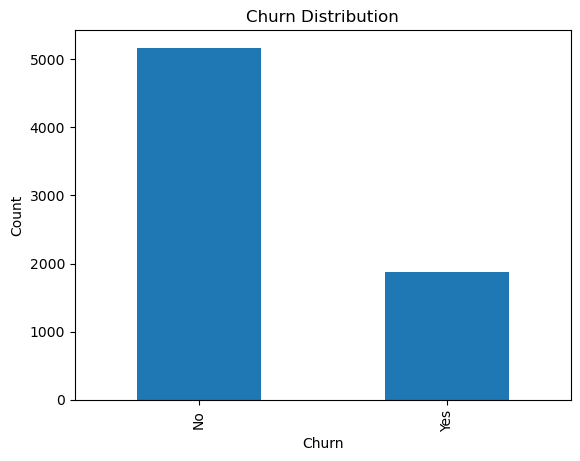

In [15]:
df['Churn'].value_counts().plot(kind='bar')
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

### Step 4.2: Monthly Charges vs Churn

- Are churn customers paying more?

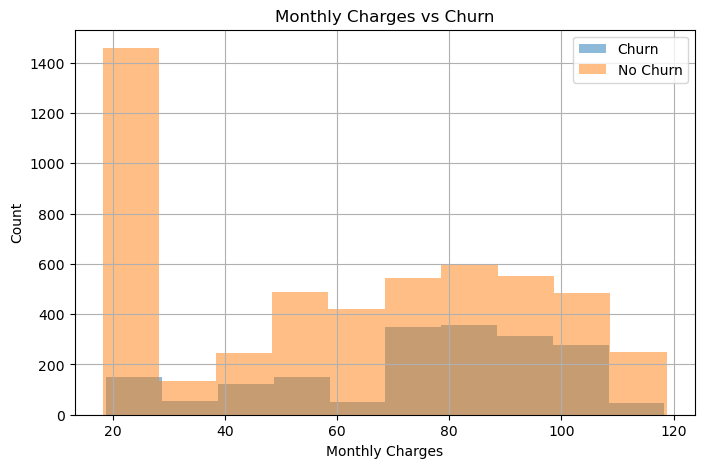

In [16]:
plt.figure(figsize=(8,5))
df[df['Churn']=='Yes']['MonthlyCharges'].hist(alpha=0.5, label='Churn')
df[df['Churn']=='No']['MonthlyCharges'].hist(alpha=0.5, label='No Churn')
plt.legend()
plt.title("Monthly Charges vs Churn")
plt.xlabel("Monthly Charges")
plt.ylabel("Count")
plt.show()


### Step 4.3: Tenure vs Churn
- Customers with low tenure leave more

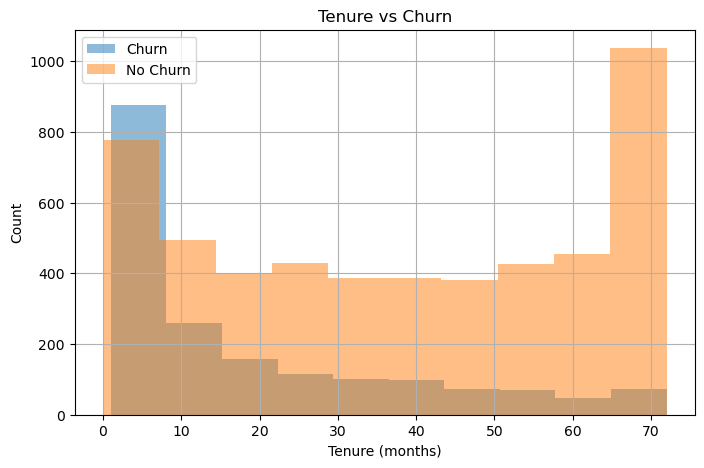

In [17]:
plt.figure(figsize=(8,5))
df[df['Churn']=='Yes']['tenure'].hist(alpha=0.5, label='Churn')
df[df['Churn']=='No']['tenure'].hist(alpha=0.5, label='No Churn')
plt.legend()
plt.title("Tenure vs Churn")
plt.xlabel("Tenure (months)")
plt.ylabel("Count")
plt.show()

### Step 4.4: Contract Type vs Churn

- Expected insight:
    - Month-to-month customers churn more

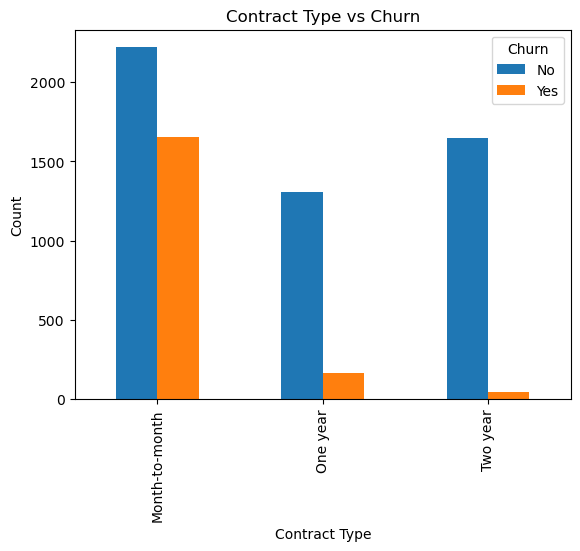

In [18]:
pd.crosstab(df['Contract'], df['Churn']).plot(kind='bar')
plt.title("Contract Type vs Churn")
plt.xlabel("Contract Type")
plt.ylabel("Count")
plt.show()

### Step 4.5: Payment Method vs Churn

- Expected insight:
    - Customers who pay electronically churn less

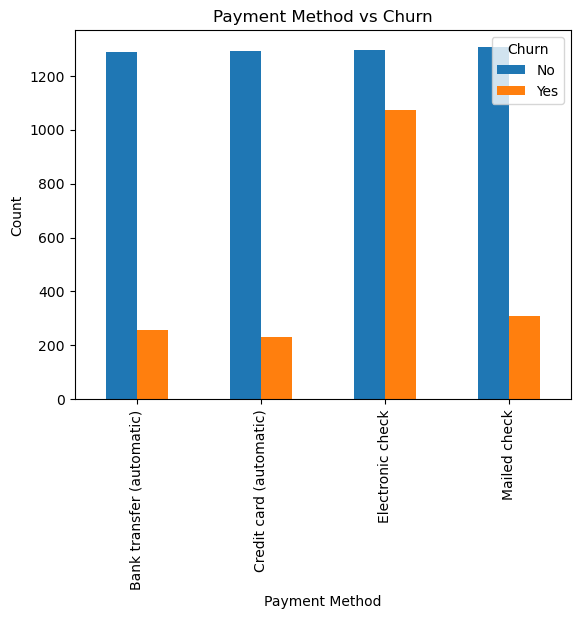

In [19]:
pd.crosstab(df['PaymentMethod'], df['Churn']).plot(kind='bar')
plt.title("Payment Method vs Churn")
plt.xlabel("Payment Method")
plt.ylabel("Count")
plt.show()

### Step 4.6: Internet Service vs Churn

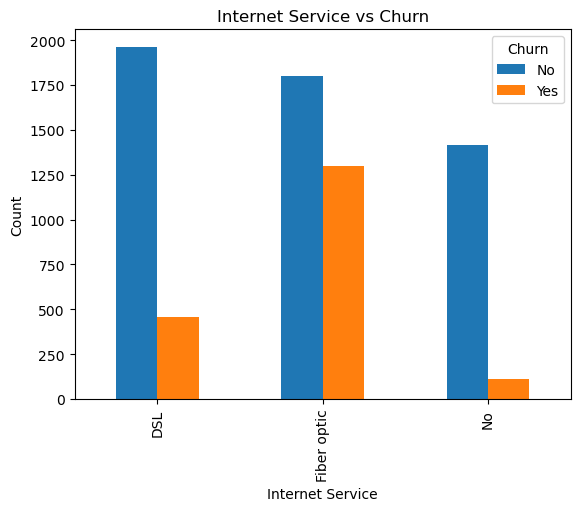

In [20]:
pd.crosstab(df['InternetService'], df['Churn']).plot(kind='bar')
plt.title("Internet Service vs Churn")
plt.xlabel("Internet Service")
plt.ylabel("Count")
plt.show()

### Step 4.7: Key Insight from EDA

1. Customers with low tenure are more likely to churn

2. Month-to-month contracts have higher churn rates

3. Customers with higher monthly charges show increased churn risk

4. Churn dataset is imbalanced (27% churn rate)

## Step 5: Data Cleaning + Feature Engineering

- Transitioning from "analysis" to "machine learning".
- Preparing before cooking

### Goal:
Converting raw data --> model-ready data so the model can understand everything.

### Step 5.1: Remove Unnessary column

In [21]:
# Drop customerID (not useful for prediction)
df = df.drop('customerID', axis=1)

### 5.2: Fix TotalCharges
- This column looks numeric but is actually text.

In [23]:
### 5.2: Fix TotalCharges - the column looks numeric but is text.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check missing values:
df['TotalCharges'].isnull().sum()

11

In [ ]:
# Fix missing values with median - models can't handle text or missing values
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Check missing values again
df['TotalCharges'].isnull().sum()


0

### Step 5.3: Convert target variable(Churn)

In [26]:
# Convert churn to binary variable  
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Check the result
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

### Step 5.4: Encode Categorical variables

- Most columns are text - models need numbers.

#### Why drop_first = True - It avoids duplicate columns (important for models)

In [ ]:
# Convert categorical variables using one-hot encoding
df = pd.get_dummies(df, drop_first=True)

# Convert false/true to 0/1
df = df.astype(int)

# Check the result
df.head()





,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29,29,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56,1889,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53,108,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42,1840,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70,151,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0


### Step 5.5: Split features and target

In [30]:
# Separate features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

### Step 5.6: Train-test-split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Step 5.7: Feature scaling

#### Standardize features
Important for some models

- fit_transform --> only on training data
- transform --> only on test data. Why? To avoid leakage

In [34]:
from sklearn.preprocessing import StandardScaler 

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Data Preprocessing Summary

- Removed irrelevant identifier column (customerID)
- Converted TotalCharges to numeric and handled missing values
- Encoded categorical variables using one-hot encoding
- Split data into training and testing sets
- Applied feature scaling using StandardScaler

## Step 6: Model Training

`Goal`
- Train models to answer:
    - "Will this customer churn or not?"

### Step 6.1: Import Models

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


### Step 6.2: Train Logistic Regression

- Start with a simple model.

In [35]:
# Logistic Regression
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

### 6.3: Make Predictions

In [36]:
y_pred_log = log_model.predict(X_test)

### 6.4: Evaluate Logistic Regression

In [37]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

# Accuracy
accuracy_log = accuracy_score(y_test, y_pred_log)
print(f"Accuracy: {accuracy_log:.4f}")

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred_log))

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

# ROC AUC Score
roc_auc_log = roc_auc_score(y_test, y_pred_log)
print(f"ROC - AUC Score:", roc_auc_score(y_test, log_model.predict_proba(X_test)[:,1]))

# ROC Curve
fpr_log, tpr_log, thresholds_log = roc_curve(y_test, y_pred_log)


Accuracy: 0.8070
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

Confusion Matrix:
[[925 110]
 [162 212]]
ROC - AUC Score: 0.8416078948048258


## Model Evaluation Results (Interpretation)

### Accuracy: 0.807  
The model correctly predicts customer churn about **80.7% of the time**.

---

### Precision (Churn = 1): 0.66  
When the model predicts a customer will churn, it is correct **66% of the time**.  
This means some customers are incorrectly flagged as churn.

---

### Recall (Churn = 1): 0.57  
The model correctly identifies **57% of actual churned customers**.  
This means it is missing some customers who are actually leaving.

---

### F1-Score (Churn = 1): 0.61  
The balance between precision and recall is **moderate**, indicating room for improvement in detecting churn.

---

### Confusion Matrix Interpretation  

- True Negatives (Correctly predicted no churn): 925  
- False Positives (Predicted churn but did not): 110  
- False Negatives (Missed churn customers): 162  
- True Positives (Correctly predicted churn): 212  

This shows the model is better at predicting **non-churn customers** than churn customers.

---

### ROC-AUC Score: 0.842  
The model has a **strong ability to distinguish** between churn and non-churn customers.  
A score of 0.84 indicates good overall model performance.

---

### Key Insight  
The model performs well overall, but **recall for churn is relatively low (57%)**, meaning some at-risk customers are not being identified. Improving recall would be important for business use cases where preventing churn is critical.

### Step 6.5: Train Decision Tree

In [ ]:
# Training Decision Tree
tree_model = DecisionTreeClassifier()
tree_model.fit(X_train, y_train)


DecisionTreeClassifier()

### 6.6: Make Predictions

In [40]:
y_pred_tree = tree_model.predict(X_test)

### 6.7: Evaluate Decision Tree

In [41]:
# Evaluate Decison Tree
print("=== Decision Tree Model Evaluation ===")

print(f"Accuracy: {accuracy_score(y_test, y_pred_tree):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tree))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tree))

roc_auc = roc_auc_score(y_test, tree_model.predict_proba(X_test)[:,1])
print(f"\nROC-AUC Score: {roc_auc:.4f}")

=== Decision Tree Model Evaluation ===
Accuracy: 0.7211

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.81      0.81      1035
           1       0.47      0.48      0.48       374

    accuracy                           0.72      1409
   macro avg       0.64      0.64      0.64      1409
weighted avg       0.72      0.72      0.72      1409

Confusion Matrix:
[[837 198]
 [195 179]]

ROC-AUC Score: 0.6498


## Decision Tree Model Evaluation (Interpretation)

### Accuracy: 0.721  
The Decision Tree model correctly predicts churn about **72.1% of the time**, which is lower than other models tested.

---

### Precision (Churn = 1): 0.47  
When the model predicts a customer will churn, it is correct only **47% of the time**.  
This indicates a higher number of false positives.

---

### Recall (Churn = 1): 0.48  
The model correctly identifies **48% of actual churn customers**, meaning it misses more than half of them.

---

### F1-Score (Churn = 1): 0.48  
The balance between precision and recall is relatively low, indicating weaker performance in identifying churn.

---

### Confusion Matrix Interpretation  

- True Negatives: 837 (correctly predicted no churn)  
- False Positives: 198 (predicted churn but did not)  
- False Negatives: 195 (missed churn customers)  
- True Positives: 179 (correctly predicted churn)  

The model struggles to correctly identify churn customers.

---

### ROC-AUC Score: 0.650  
The model has **weak ability to distinguish** between churn and non-churn customers compared to other models.

---

### Key Insight  
The Decision Tree model performs worse than Logistic Regression and Random Forest.  
It shows lower recall and ROC-AUC, indicating it is not as effective at identifying customers who are likely to churn.

This is likely due to **overfitting and lack of generalization**, which is a common limitation of basic decision trees.

---

### Conclusion  
While Decision Trees are simple and easy to interpret, they are not the best choice for this problem.  
More advanced models like Random Forest provide better performance and generalization.

## Step 6.8: Train Random Forest

Now a stronger model.

- Random Forest does not need scaling.

In [42]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

### Step 6.9: Predict with Random Forest

In [43]:
y_pred_rf = rf_model.predict(X_test)

### Step 6.10: Evaluate Random Forest

In [44]:
print("=== Random Forest Model Evaluation ===")

print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))


=== Random Forest Model Evaluation ===
Accuracy: 0.7921

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.51      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



## Random Forest Model Evaluation (Interpretation)

### Accuracy: 0.792  
The Random Forest model correctly predicts churn about **79.2% of the time**, showing strong overall performance.

---

### Precision (Churn = 1): 0.64  
When the model predicts a customer will churn, it is correct **64% of the time**.  
This is a solid precision score, meaning fewer false alarms compared to weaker models.

---

### Recall (Churn = 1): 0.51  
The model correctly identifies **51% of actual churn customers**, meaning it still misses about half of the customers who churn.

---

### F1-Score (Churn = 1): 0.56  
The balance between precision and recall is **moderate**, indicating decent but improvable churn detection.

---

### Key Insight  
The Random Forest model performs better than Decision Tree and is competitive with Logistic Regression.

- It achieves strong overall accuracy  
- It reduces overfitting compared to a single decision tree  
- It captures more complex patterns in the data  

---

### Model Behavior  
The model is better at predicting **non-churn customers (Class 0)** than churn customers (Class 1), which is common in imbalanced datasets.

---

### Conclusion  
Random Forest is one of the best-performing models in this project.  
However, improving **recall for churn customers** should be a priority to better identify at-risk customers.

Possible improvements:
- Hyperparameter tuning  
- Class balancing techniques  
- Threshold adjustment  

## Model Comparison Summary

| Model                | Accuracy | Recall (Churn) | ROC-AUC | Notes |
|---------------------|---------|----------------|--------|------|
| Logistic Regression | ~0.81   | 0.57           | ~0.84  | Best overall balance |
| Random Forest       | 0.79    | 0.51           | ~0.84* | Strong, but slightly lower recall |
| Decision Tree       | 0.72    | 0.48           | 0.65   | Weak, likely overfitting |

*ROC-AUC for Random Forest expected similar to Logistic Regression

## Big Insight

**All the models have:**

- Lower recall for churn (~0.5–0.57)

**Meaning:**

- The model is missing many customers who will leave

- This is a real-world ML problem (class imbalance).